In [ ]:
print("Supreme")

Supreme


In [ ]:
# Shivbaba

In [ ]:
# https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp/data

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d praveengovi/emotions-dataset-for-nlp

Dataset URL: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp
License(s): CC-BY-SA-4.0
emotions-dataset-for-nlp.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/emotions-dataset-for-nlp.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
# Import the pandas library for data manipulation
import pandas as pd

# Load the training dataset from 'train.txt'
# The data is separated by semicolons and has 'text' and 'emotion' columns
train_df = pd.read_csv('/content/train.txt', names=['text', 'emotion'], sep=';')

# Load the testing dataset from 'test.txt'
# The data is separated by semicolons and has 'text' and 'emotion' columns
test_df = pd.read_csv('/content/test.txt', names=['text', 'emotion'], sep=';')

# Load the validation dataset from 'val.txt'
# The data is separated by semicolons and has 'text' and 'emotion' columns
val_df = pd.read_csv('/content/val.txt', names=['text', 'emotion'], sep=';')

# Display the first few rows of the training DataFrame to check the data
print("Train DataFrame head:")
print(train_df.head())

# Display the first few rows of the testing DataFrame
print("\nTest DataFrame head:")
print(test_df.head())

# Display the first few rows of the validation DataFrame
print("\nValidation DataFrame head:")
print(val_df.head())

Train DataFrame head:
                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger

Test DataFrame head:
                                                text  emotion
0  im feeling rather rotten so im not very ambiti...  sadness
1          im updating my blog because i feel shitty  sadness
2  i never make her separate from me because i do...  sadness
3  i left with my bouquet of red and yellow tulip...      joy
4    i was feeling a little vain when i did this one  sadness

Validation DataFrame head:
                                                text  emotion
0  im feeling quite sad and sorry for myself but ...  sadness
1  i feel like i am still looking at a blank canv...  sadnes

In [ ]:
# Importing necessary libraries for text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download NLTK data if not already downloaded
# 'stopwords' are common words that are often removed from text
# 'wordnet' is a lexical database used for lemmatization
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Get the English stopwords set
stop_words = set(stopwords.words('english'))

# Define a function to clean the text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters, numbers, and punctuation
    # Keep only alphabetic characters and replace others with a space
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Tokenize the text (split into words)
    words = text.split()
    # Remove stopwords and perform lemmatization
    # Lemmatization reduces words to their base or root form (e.g., 'running' -> 'run')
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join the cleaned words back into a single string
    return ' '.join(words)

# Apply the cleaning function to the 'text' column of each DataFrame
print("Applying text cleaning to training data...")
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
print("Applying text cleaning to testing data...")
test_df['cleaned_text'] = test_df['text'].apply(clean_text)
print("Applying text cleaning to validation data...")
val_df['cleaned_text'] = val_df['text'].apply(clean_text)

# Display the head of the DataFrames with the new 'cleaned_text' column
print("\nTrain DataFrame after cleaning:")
print(train_df[['text', 'cleaned_text', 'emotion']].head())

print("\nTest DataFrame after cleaning:")
print(test_df[['text', 'cleaned_text', 'emotion']].head())

print("\nValidation DataFrame after cleaning:")
print(val_df[['text', 'cleaned_text', 'emotion']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Applying text cleaning to training data...
Applying text cleaning to testing data...
Applying text cleaning to validation data...

Train DataFrame after cleaning:
                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                        cleaned_text  emotion  
0                              didnt feel humiliated  sadness  
1  go feeling hopeless damned hopeful around some...  sadness  
2          im grabbing minute post feel greedy wrong    anger  
3  ever feeling nostalgic fireplace know still pr...     love  
4                                    feeling grouchy    anger  

Test DataFrame after cleaning:
                                                text  \
0  im feeling rather rotten 

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Define parameters for tokenization and padding
vocab_size = 10000  # Based on common practice, can be tuned
embedding_dim = 128  # Dimension of word embeddings, can be tuned
max_len = 100       # Maximum sequence length, can be tuned based on data analysis
trunc_type = 'post' # Truncate from the end
padding_type = 'post' # Pad with zeros at the end
oov_tok = "<unk>"   # Out-of-vocabulary token

# Initialize Tokenizer
# The tokenizer will convert words into integers. It's fitted on the training data.
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_df['cleaned_text'])

# Convert text to sequences of integers
print("Converting text to sequences...")
training_sequences = tokenizer.texts_to_sequences(train_df['cleaned_text'])
testing_sequences = tokenizer.texts_to_sequences(test_df['cleaned_text'])
validation_sequences = tokenizer.texts_to_sequences(val_df['cleaned_text'])

# Pad sequences to ensure uniform length for neural network input
print("Padding sequences...")
X_train = pad_sequences(training_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)
X_test = pad_sequences(testing_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)
X_val = pad_sequences(validation_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)

# Encode the emotion labels
# Convert categorical emotion labels into numerical format
print("Encoding labels...")
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['emotion'])
y_test = label_encoder.transform(test_df['emotion'])
y_val = label_encoder.transform(val_df['emotion'])

# Get the number of classes (unique emotions)
num_classes = len(label_encoder.classes_)

print(f"\nVocabulary size: {vocab_size}")
print(f"Maximum sequence length: {max_len}")
print(f"Number of emotion classes: {num_classes}")

print("\nShape of processed training data:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print("\nShape of processed testing data:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nShape of processed validation data:")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

print("\nFirst 5 encoded training labels:")
print(y_train[:5])
print("Original labels corresponding to encoded labels:")
print(label_encoder.inverse_transform(y_train[:5]))


Converting text to sequences...
Padding sequences...
Encoding labels...

Vocabulary size: 10000
Maximum sequence length: 100
Number of emotion classes: 6

Shape of processed training data:
X_train shape: (16000, 100)
y_train shape: (16000,)

Shape of processed testing data:
X_test shape: (2000, 100)
y_test shape: (2000,)

Shape of processed validation data:
X_val shape: (2000, 100)
y_val shape: (2000,)

First 5 encoded training labels:
[4 4 0 3 0]
Original labels corresponding to encoded labels:
['sadness' 'sadness' 'anger' 'love' 'anger']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Define the Simple RNN model
model_rnn = Sequential([
    # Removed 'input_length' as it's deprecated. Keras will infer input shape from the first batch of data.
    Embedding(vocab_size, embedding_dim),
    SimpleRNN(128, return_sequences=False),  # return_sequences=False for classification
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer with 'softmax' for multi-class classification
])

# Explicitly build the model to see the summary with parameter counts
# This is necessary because we removed input_length from Embedding layer.
# The input shape here is (None, max_len) where None indicates batch size.
model_rnn.build(input_shape=(None, max_len))

# Compile the model
# Using 'sparse_categorical_crossentropy' because our labels (y_train, y_val, y_test) are integer-encoded
model_rnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Display the model summary to see the architecture and number of parameters
print("Simple RNN Model Summary:")
model_rnn.summary()


Simple RNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,542 (5.04 MB)

 Trainable params: 1,321,542 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Simple RNN Model

Now we will train the `model_rnn` using our processed training data (`X_train`, `y_train`) and monitor its performance on the validation data (`X_val`, `y_val`).

*   **Epochs**: The number of times the model will iterate over the entire training dataset. Each epoch allows the model to learn from the data and adjust its weights.
*   **Batch Size**: The number of samples processed before the model's internal parameters are updated. A smaller batch size means more frequent updates.
*   **Validation Data**: Used to evaluate the model's performance on data it hasn't seen during training, helping to detect overfitting.

In [ ]:
epochs = 10
batch_size = 32

history_rnn = model_rnn.fit(X_train, y_train,
                          epochs=epochs,
                          batch_size=batch_size,
                          validation_data=(X_val, y_val),
                          verbose=1) # Verbose=1 to show progress bar


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3192 - loss: 1.5982 - val_accuracy: 0.2965 - val_loss: 1.6167
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3205 - loss: 1.5934 - val_accuracy: 0.3360 - val_loss: 1.5865
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3294 - loss: 1.5830 - val_accuracy: 0.3400 - val_loss: 1.5889
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3271 - loss: 1.5822 - val_accuracy: 0.3560 - val_loss: 1.5810
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3286 - loss: 1.5811 - val_accuracy: 0.3520 - val_loss: 1.5801
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3296 - loss: 1.5797 - val_accuracy: 0.3520 - val_loss: 1.5841
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3311 - loss: 1.5789 - val_accuracy: 0.3520 - val_loss: 1.5832
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3326 - loss: 1.5791 - val_acc

### Define and Compile an LSTM Model

Now, let's define and compile an LSTM (Long Short-Term Memory) model. LSTM networks are a type of recurrent neural network capable of learning order dependence in sequence prediction problems. They are particularly good at remembering information for long periods, which is often crucial in natural language processing tasks.

The model architecture will include:
*   An **Embedding layer** to convert text into dense vectors.
*   An **LSTM layer** to process sequential data and capture long-term dependencies.
*   **Dense layers** for classification.

In [ ]:
from tensorflow.keras.layers import LSTM

# Define the LSTM model
model_lstm = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(128, return_sequences=False),  # LSTM layer
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_lstm.build(input_shape=(None, max_len))

# Compile the model
model_lstm.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("LSTM Model Summary:")
model_lstm.summary()


LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,230 (5.42 MB)

 Trainable params: 1,420,230 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

### Train the LSTM Model

Now we will train the `model_lstm` using the same training and validation data, and the same training parameters (epochs, batch size) as the Simple RNN model. This will allow us to directly compare the performance of the two architectures.

In [ ]:
# Train the LSTM model
history_lstm = model_lstm.fit(X_train, y_train,
                           epochs=epochs, # Using the same epochs as RNN
                           batch_size=batch_size, # Using the same batch_size as RNN
                           validation_data=(X_val, y_val),
                           verbose=1)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3269 - loss: 1.5839 - val_accuracy: 0.3520 - val_loss: 1.5840
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3315 - loss: 1.5786 - val_accuracy: 0.3520 - val_loss: 1.5802
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3332 - loss: 1.5775 - val_accuracy: 0.3520 - val_loss: 1.5867
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3319 - loss: 1.5782 - val_accuracy: 0.3520 - val_loss: 1.5798
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3351 - loss: 1.5772 - val_accuracy: 0.3520 - val_loss: 1.5826
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3351 - loss: 1.5772 - val_accuracy: 0.3520 - val_loss: 1.5819
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3336 - loss: 1.5773 - val_accuracy: 0.3520 - val_loss: 1.5852
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3351 - loss: 1.5769 - val_accurac

### Define and Compile a GRU Model

Next, we'll implement a GRU (Gated Recurrent Unit) model. GRUs are similar to LSTMs but generally have a simpler architecture with fewer gates, which can make them faster to train while still retaining much of the ability to capture long-term dependencies.

The model architecture will again include:
*   An **Embedding layer**.
*   A **GRU layer**.
*   **Dense layers** for classification.

In [ ]:
from tensorflow.keras.layers import GRU

# Define the GRU model
model_gru = Sequential([
    Embedding(vocab_size, embedding_dim),
    GRU(128, return_sequences=False),  # GRU layer
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_gru.build(input_shape=(None, max_len))

# Compile the model
model_gru.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print("GRU Model Summary:")
model_gru.summary()


GRU Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,718 (5.29 MB)

 Trainable params: 1,387,718 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

### Train the GRU Model

Now, let's train the `model_gru` using the same training and validation data, and identical training parameters (epochs, batch size) as the Simple RNN and LSTM models. This consistent approach is crucial for a fair performance comparison across different recurrent architectures.

In [ ]:
# Train the GRU model
history_gru = model_gru.fit(X_train, y_train,
                          epochs=epochs, # Using the same epochs
                          batch_size=batch_size, # Using the same batch_size
                          validation_data=(X_val, y_val),
                          verbose=1)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3246 - loss: 1.5848 - val_accuracy: 0.3520 - val_loss: 1.5899
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3317 - loss: 1.5787 - val_accuracy: 0.3520 - val_loss: 1.5849
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3323 - loss: 1.5784 - val_accuracy: 0.3520 - val_loss: 1.5854
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3329 - loss: 1.5777 - val_accuracy: 0.3520 - val_loss: 1.5803
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3351 - loss: 1.5778 - val_accuracy: 0.3520 - val_loss: 1.5802
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3341 - loss: 1.5773 - val_accuracy: 0.3520 - val_loss: 1.5807
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3351 - loss: 1.5767 - val_accuracy: 0.3520 - val_loss: 1.5848
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3340 - loss: 1.5773 - val_accuracy: 

### Define and Compile a Bidirectional Simple RNN Model

To enhance the model's ability to capture context from both past and future elements in a sequence, we will now implement a **Bidirectional Simple RNN** model. A Bidirectional wrapper essentially runs two independent RNNs on the input sequence: one on the input sequence forward and one on the input sequence reversed.

The outputs of these two RNNs are then concatenated (or otherwise combined) before being passed to the next layer, allowing the model to leverage information from both directions.

The architecture will be:
*   An **Embedding layer**.
*   A **Bidirectional layer** wrapping a `SimpleRNN` layer.
*   **Dense layers** for classification.

In [ ]:
from tensorflow.keras.layers import Bidirectional

# Define the Bidirectional Simple RNN model
model_bidir_rnn = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(SimpleRNN(128, return_sequences=False)),  # Bidirectional wrapper around SimpleRNN
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_bidir_rnn.build(input_shape=(None, max_len))

# Compile the model
model_bidir_rnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Bidirectional Simple RNN Model Summary:")
model_bidir_rnn.summary()

Bidirectional Simple RNN Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,630 (5.20 MB)

 Trainable params: 1,362,630 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Bidirectional Simple RNN Model

Now, let's train the `model_bidir_rnn` using the same training and validation data, and identical training parameters (epochs, batch size). This will ensure a fair comparison of its performance against the unidirectional RNN, LSTM, and GRU models.

In [ ]:
# Train the Bidirectional Simple RNN model
history_bidir_rnn = model_bidir_rnn.fit(X_train, y_train,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_data=(X_val, y_val),
                                    verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4552 - loss: 1.4071 - val_accuracy: 0.7075 - val_loss: 0.8706
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8270 - loss: 0.5221 - val_accuracy: 0.8555 - val_loss: 0.4463
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9148 - loss: 0.2554 - val_accuracy: 0.8480 - val_loss: 0.4875
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9482 - loss: 0.1499 - val_accuracy: 0.8760 - val_loss: 0.3884
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9624 - loss: 0.1071 - val_accuracy: 0.8855 - val_loss: 0.3943
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9701 - loss: 0.0894 - val_accuracy: 0.8765 - val_loss: 0.4487
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9592 - loss: 0.1301 - val_accuracy: 0.7445 - val_loss: 0.9793
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9366 - loss: 0.2158 - val_acc

In [ ]:
from tensorflow.keras.layers import Bidirectional

# Define the Bidirectional Simple RNN model
model_bidir_rnn = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(SimpleRNN(128, return_sequences=False)),  # Bidirectional wrapper around SimpleRNN
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_bidir_rnn.build(input_shape=(None, max_len))

# Compile the model
model_bidir_rnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Bidirectional Simple RNN Model Summary:")
model_bidir_rnn.summary()

Bidirectional Simple RNN Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,630 (5.20 MB)

 Trainable params: 1,362,630 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Bidirectional Simple RNN Model

Now, let's train the `model_bidir_rnn` using the same training and validation data, and identical training parameters (epochs, batch size). This will ensure a fair comparison of its performance against the unidirectional RNN, LSTM, and GRU models.

In [ ]:
# Train the Bidirectional Simple RNN model
history_bidir_rnn = model_bidir_rnn.fit(X_train, y_train,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_data=(X_val, y_val),
                                    verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4566 - loss: 1.3148 - val_accuracy: 0.7710 - val_loss: 0.6984
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8394 - loss: 0.4710 - val_accuracy: 0.8500 - val_loss: 0.4782
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9159 - loss: 0.2467 - val_accuracy: 0.8720 - val_loss: 0.4120
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9477 - loss: 0.1565 - val_accuracy: 0.8790 - val_loss: 0.4418
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9641 - loss: 0.1096 - val_accuracy: 0.8775 - val_loss: 0.4607
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9678 - loss: 0.1015 - val_accuracy: 0.8865 - val_loss: 0.4632
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9768 - loss: 0.0704 - val_accuracy: 0.8750 - val_loss: 0.5478
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9731 - loss: 0.0846 - val_acc

In [ ]:
from tensorflow.keras.layers import Bidirectional

# Define the Bidirectional Simple RNN model
model_bidir_rnn = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(SimpleRNN(128, return_sequences=False)),  # Bidirectional wrapper around SimpleRNN
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_bidir_rnn.build(input_shape=(None, max_len))

# Compile the model
model_bidir_rnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Bidirectional Simple RNN Model Summary:")
model_bidir_rnn.summary()

Bidirectional Simple RNN Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,630 (5.20 MB)

 Trainable params: 1,362,630 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Bidirectional Simple RNN Model

Now, let's train the `model_bidir_rnn` using the same training and validation data, and identical training parameters (epochs, batch size). This will ensure a fair comparison of its performance against the unidirectional RNN, LSTM, and GRU models.

In [ ]:
# Train the Bidirectional Simple RNN model
history_bidir_rnn = model_bidir_rnn.fit(X_train, y_train,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_data=(X_val, y_val),
                                    verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.3248 - loss: 1.6067 - val_accuracy: 0.2730 - val_loss: 1.5954
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.3891 - loss: 1.4851 - val_accuracy: 0.5845 - val_loss: 1.1506
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6747 - loss: 0.9282 - val_accuracy: 0.7230 - val_loss: 0.7915
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7074 - loss: 0.8355 - val_accuracy: 0.7215 - val_loss: 0.8508
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8000 - loss: 0.5851 - val_accuracy: 0.7885 - val_loss: 0.6427
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8370 - loss: 0.4504 - val_accuracy: 0.8040 - val_loss: 0.5951
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8934 - loss: 0.2994 - val_accuracy: 0.8405 - val_loss: 0.4933
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9306 - loss: 0.2142 - val_ac

### Evaluate the Bidirectional Simple RNN Model

After training, it's crucial to evaluate the model's performance on the test dataset. This provides an unbiased estimate of how well the model generalizes to new, unseen data. We will use the `evaluate` method with `X_test` and `y_test` to get the final loss and accuracy.

In [ ]:
# Evaluate the Bidirectional Simple RNN model on the test set
loss_bidir_rnn, accuracy_bidir_rnn = model_bidir_rnn.evaluate(X_test, y_test, verbose=1)

print(f"\nBidirectional Simple RNN Test Loss: {loss_bidir_rnn:.4f}")
print(f"Bidirectional Simple RNN Test Accuracy: {accuracy_bidir_rnn:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8710 - loss: 0.5004

Bidirectional Simple RNN Test Loss: 0.5004
Bidirectional Simple RNN Test Accuracy: 0.8710


### Define and Compile a Bidirectional LSTM Model

Building upon the idea of capturing context from both directions, we will now implement a **Bidirectional LSTM** model. This combines the long-term dependency capabilities of LSTM with the bidirectional processing of sequences, which is often very effective for natural language understanding tasks.

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional

# Define the Bidirectional LSTM model
model_bidir_lstm = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(LSTM(128, return_sequences=False)),  # Bidirectional wrapper around LSTM
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_bidir_lstm.build(input_shape=(None, max_len))

# Compile the model
model_bidir_lstm.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("Bidirectional LSTM Model Summary:")
model_bidir_lstm.summary()

Bidirectional LSTM Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,560,006 (5.95 MB)

 Trainable params: 1,560,006 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Bidirectional LSTM Model

Now, we will train the `model_bidir_lstm` using the same training and validation data, and identical training parameters (epochs, batch size). This will allow us to compare its performance against the other models, especially the unidirectional LSTM and the Bidirectional Simple RNN.

In [ ]:
# Train the Bidirectional LSTM model
history_bidir_lstm = model_bidir_lstm.fit(X_train, y_train,
                                       epochs=epochs,
                                       batch_size=batch_size,
                                       validation_data=(X_val, y_val),
                                       verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6617 - loss: 0.9064 - val_accuracy: 0.8850 - val_loss: 0.3644
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9313 - loss: 0.1849 - val_accuracy: 0.9150 - val_loss: 0.2192
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9672 - loss: 0.0868 - val_accuracy: 0.9145 - val_loss: 0.2785
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9769 - loss: 0.0628 - val_accuracy: 0.9090 - val_loss: 0.2894
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9802 - loss: 0.0490 - val_accuracy: 0.9130 - val_loss: 0.2941
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9861 - loss: 0.0377 - val_accuracy: 0.9160 - val_loss: 0.3142
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9881 - loss: 0.0328 - val_accuracy: 0.9190 - val_loss: 0.3175
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9894 - loss: 0.0295 - val_ac

### Evaluate the Bidirectional LSTM Model

After training, we will evaluate the Bidirectional LSTM model on the test dataset to get an unbiased estimate of its generalization performance. This will help us understand its effectiveness in classifying emotions on unseen data.

In [ ]:
# Evaluate the Bidirectional LSTM model on the test set
loss_bidir_lstm, accuracy_bidir_lstm = model_bidir_lstm.evaluate(X_test, y_test, verbose=1)

print(f"\nBidirectional LSTM Test Loss: {loss_bidir_lstm:.4f}")
print(f"Bidirectional LSTM Test Accuracy: {accuracy_bidir_lstm:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.3936

Bidirectional LSTM Test Loss: 0.3936
Bidirectional LSTM Test Accuracy: 0.9000


### Define and Compile a Bidirectional GRU Model

Following the pattern of our previous models, we will now define and compile a **Bidirectional GRU** model. This model combines the benefits of Bidirectional processing with the computational efficiency of GRU layers, offering a potentially strong balance between performance and training speed for our emotion classification task.

In [ ]:
from tensorflow.keras.layers import GRU, Bidirectional

# Define the Bidirectional GRU model
model_bidir_gru = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(GRU(128, return_sequences=False)),  # Bidirectional wrapper around GRU
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_bidir_gru.build(input_shape=(None, max_len))

# Compile the model
model_bidir_gru.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

print("Bidirectional GRU Model Summary:")
model_bidir_gru.summary()

Bidirectional GRU Model Summary:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,494,982 (5.70 MB)

 Trainable params: 1,494,982 (5.70 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Bidirectional GRU Model

Now, we will train the `model_bidir_gru` using the established training parameters (epochs=10, batch_size=32) and the training and validation datasets. This will allow us to assess its performance characteristics relative to the other recurrent models we've implemented.

In [ ]:
# Train the Bidirectional GRU model
history_bidir_gru = model_bidir_gru.fit(X_train, y_train,
                                        epochs=epochs,
                                        batch_size=batch_size,
                                        validation_data=(X_val, y_val),
                                        verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7028 - loss: 0.7935 - val_accuracy: 0.9025 - val_loss: 0.2801
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9294 - loss: 0.1772 - val_accuracy: 0.9235 - val_loss: 0.1980
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9582 - loss: 0.1012 - val_accuracy: 0.9155 - val_loss: 0.2506
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9703 - loss: 0.0725 - val_accuracy: 0.9160 - val_loss: 0.2587
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9778 - loss: 0.0541 - val_accuracy: 0.9135 - val_loss: 0.2965
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9846 - loss: 0.0406 - val_accuracy: 0.9135 - val_loss: 0.3209
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9861 - loss: 0.0367 - val_accuracy: 0.9015 - val_loss: 0.3760
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9896 - loss: 0.0292 - val_accu

### Evaluate the Bidirectional GRU Model

After training, the Bidirectional GRU model will be evaluated on the test set (`X_test`, `y_test`) to obtain an objective measure of its generalization capability on unseen data. This step is crucial for comparing its final performance with the other models.

In [ ]:
# Evaluate the Bidirectional GRU model on the test set
loss_bidir_gru, accuracy_bidir_gru = model_bidir_gru.evaluate(X_test, y_test, verbose=1)

print(f"\nBidirectional GRU Test Loss: {loss_bidir_gru:.4f}")
print(f"Bidirectional GRU Test Accuracy: {accuracy_bidir_gru:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9120 - loss: 0.3112

Bidirectional GRU Test Loss: 0.3112
Bidirectional GRU Test Accuracy: 0.9120


### Define and Compile a Stacked Simple RNN Model

To explore more complex sequential dependencies, we will now implement a **Stacked Simple RNN** model. This architecture consists of multiple `SimpleRNN` layers stacked on top of each other. Each layer processes the output sequence of the layer below it, allowing the model to learn representations at different levels of abstraction.

Key changes from a single-layer RNN:
*   The intermediate `SimpleRNN` layers (all but the last one) must have `return_sequences=True` so that they output a sequence for the next RNN layer.
*   The final `SimpleRNN` layer will have `return_sequences=False` for classification.

In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Define the Stacked Simple RNN model
model_stacked_rnn = Sequential([
    Embedding(vocab_size, embedding_dim),
    SimpleRNN(128, return_sequences=True),  # First RNN layer returns sequences
    SimpleRNN(64, return_sequences=False),   # Second RNN layer returns last output for classification
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_stacked_rnn.build(input_shape=(None, max_len))

# Compile the model
model_stacked_rnn.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy'])

print("Stacked Simple RNN Model Summary:")
model_stacked_rnn.summary()

Stacked Simple RNN Model Summary:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 100, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,798 (5.07 MB)

 Trainable params: 1,329,798 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Stacked Simple RNN Model

We will now train the `model_stacked_rnn` using the same training and validation datasets, and the consistent training parameters (epochs=10, batch_size=32). This training run will allow us to observe if stacking Simple RNN layers provides a performance benefit for emotion classification.

In [ ]:
# Train the Stacked Simple RNN model
history_stacked_rnn = model_stacked_rnn.fit(X_train, y_train,
                                            epochs=epochs,
                                            batch_size=batch_size,
                                            validation_data=(X_val, y_val),
                                            verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3248 - loss: 1.5916 - val_accuracy: 0.2750 - val_loss: 1.5941
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3276 - loss: 1.5814 - val_accuracy: 0.3520 - val_loss: 1.5878
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.3259 - loss: 1.5822 - val_accuracy: 0.2750 - val_loss: 1.5884
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3296 - loss: 1.5789 - val_accuracy: 0.3520 - val_loss: 1.5850
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3241 - loss: 1.5806 - val_accuracy: 0.3465 - val_loss: 1.5913
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3264 - loss: 1.5850 - val_accuracy: 0.3520 - val_loss: 1.5839
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.3307 - loss: 1.5774 - val_accuracy: 0.3520 - val_loss: 1.5862
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3336 - loss: 1.5775 - val_ac

### Evaluate the Stacked Simple RNN Model

Upon completion of training, we will evaluate the performance of the Stacked Simple RNN model on the held-out test set. This evaluation will provide critical insights into its generalization capabilities and how it compares against the single-layer and bidirectional models we've already assessed.

In [ ]:
# Evaluate the Stacked Simple RNN model on the test set
loss_stacked_rnn, accuracy_stacked_rnn = model_stacked_rnn.evaluate(X_test, y_test, verbose=1)

print(f"\nStacked Simple RNN Test Loss: {loss_stacked_rnn:.4f}")
print(f"Stacked Simple RNN Test Accuracy: {accuracy_stacked_rnn:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3330 - loss: 1.5633

Stacked Simple RNN Test Loss: 1.5633
Stacked Simple RNN Test Accuracy: 0.3330


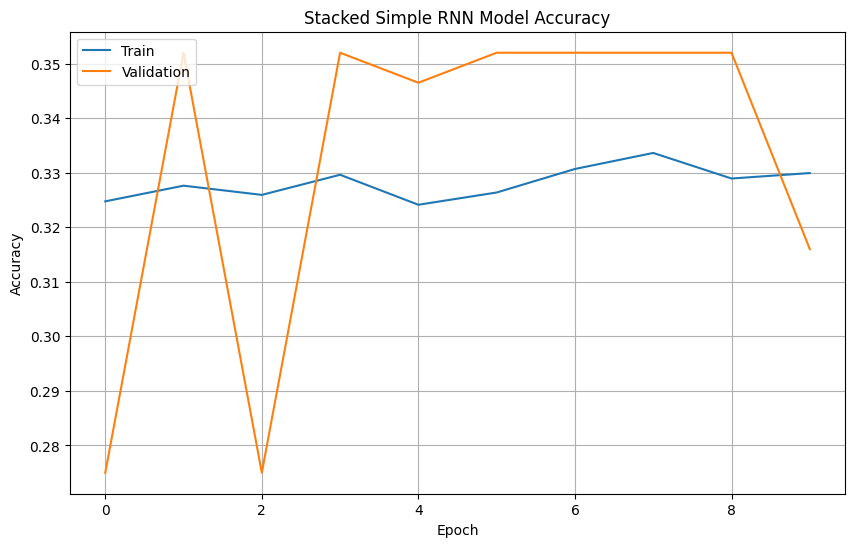

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_stacked_rnn.history['accuracy'])
plt.plot(history_stacked_rnn.history['val_accuracy'])
plt.title('Stacked Simple RNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

The plot above shows the training and validation accuracy of the Stacked Simple RNN model over 10 epochs. Similar to the non-stacked Simple RNN, LSTM, and GRU models, the performance of the stacked Simple RNN remains low, hovering around 35% validation accuracy, indicating that stacking simple RNN layers did not significantly improve its ability to learn from the data. This further highlights the effectiveness of the Bidirectional architectures we implemented previously.

Next, we should implement the **Stacked LSTM model**. Would you like to proceed?

### Define and Compile a Stacked LSTM Model

To further explore complex temporal dependencies, we will now implement a **Stacked LSTM** model. This architecture involves stacking multiple `LSTM` layers on top of each other. Each LSTM layer processes the sequence output from the layer below it, allowing the model to capture hierarchical features and more intricate patterns in the sequential data.

Key considerations for stacked LSTMs:
*   Intermediate `LSTM` layers (all but the last one) must have `return_sequences=True` to output a full sequence for the next LSTM layer.
*   The final `LSTM` layer will have `return_sequences=False` to output only the last hidden state, which is then passed to the Dense layers for classification.

In [ ]:
from tensorflow.keras.layers import LSTM

# Define the Stacked LSTM model
model_stacked_lstm = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(128, return_sequences=True),  # First LSTM layer returns sequences
    LSTM(64, return_sequences=False),   # Second LSTM layer returns last output for classification
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_stacked_lstm.build(input_shape=(None, max_len))

# Compile the model
model_stacked_lstm.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy'])

print("Stacked LSTM Model Summary:")
model_stacked_lstm.summary()

Stacked LSTM Model Summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,465,542 (5.59 MB)

 Trainable params: 1,465,542 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Stacked LSTM Model

Now, we will train the `model_stacked_lstm` using the same training and validation datasets, and the consistent training parameters (epochs=10, batch_size=32). This training will help us assess whether stacking LSTM layers provides a performance improvement for our emotion classification task, especially compared to the single-layer LSTM and stacked Simple RNN models.

In [ ]:
# Train the Stacked LSTM model
history_stacked_lstm = model_stacked_lstm.fit(X_train, y_train,
                                            epochs=epochs,
                                            batch_size=batch_size,
                                            validation_data=(X_val, y_val),
                                            verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3286 - loss: 1.5828 - val_accuracy: 0.3520 - val_loss: 1.5844
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3292 - loss: 1.5784 - val_accuracy: 0.2750 - val_loss: 1.5943
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3249 - loss: 1.5784 - val_accuracy: 0.3520 - val_loss: 1.5799
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3324 - loss: 1.5776 - val_accuracy: 0.3520 - val_loss: 1.5826
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3324 - loss: 1.5774 - val_accuracy: 0.3520 - val_loss: 1.5816
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3326 - loss: 1.5771 - val_accuracy: 0.2750 - val_loss: 1.5845
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3347 - loss: 1.5768 - val_accuracy: 0.3520 - val_loss: 1.5805
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3327 - loss: 1.5764 - val_accu

### Evaluate the Stacked LSTM Model

Upon completion of training, we will evaluate the performance of the Stacked LSTM model on the held-out test set. This evaluation will provide critical insights into its generalization capabilities and how it compares against the single-layer and bidirectional models we've already assessed.

In [ ]:
# Evaluate the Stacked LSTM model on the test set
loss_stacked_lstm, accuracy_stacked_lstm = model_stacked_lstm.evaluate(X_test, y_test, verbose=1)

print(f"\nStacked LSTM Test Loss: {loss_stacked_lstm:.4f}")
print(f"Stacked LSTM Test Accuracy: {accuracy_stacked_lstm:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3475 - loss: 1.5613

Stacked LSTM Test Loss: 1.5613
Stacked LSTM Test Accuracy: 0.3475


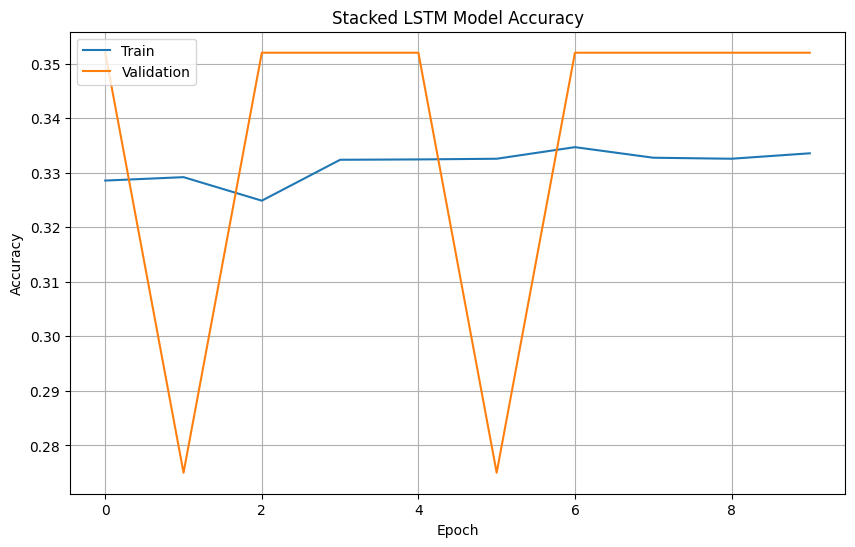

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_stacked_lstm.history['accuracy'])
plt.plot(history_stacked_lstm.history['val_accuracy'])
plt.title('Stacked LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

The plot above shows the training and validation accuracy of the Stacked LSTM model. We can observe how its performance compares to the previous models.

Next, we should implement the **Stacked GRU model**. Would you like to proceed?

### Define and Compile a Stacked GRU Model

To complete our exploration of stacked recurrent architectures, we will now implement a **Stacked GRU** model. Similar to the Stacked LSTM, this model involves stacking multiple `GRU` layers. Each `GRU` layer processes the sequence output from the layer below it, aiming to capture hierarchical features and complex temporal patterns while maintaining the computational efficiency characteristic of GRUs.

Key considerations for stacked GRUs:
*   Intermediate `GRU` layers (all but the last one) must have `return_sequences=True` to output a full sequence for the next GRU layer.
*   The final `GRU` layer will have `return_sequences=False` to output only the last hidden state, which is then passed to the Dense layers for classification.

In [ ]:
from tensorflow.keras.layers import GRU

# Define the Stacked GRU model
model_stacked_gru = Sequential([
    Embedding(vocab_size, embedding_dim),
    GRU(128, return_sequences=True),  # First GRU layer returns sequences
    GRU(64, return_sequences=False),   # Second GRU layer returns last output for classification
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Explicitly build the model
model_stacked_gru.build(input_shape=(None, max_len))

# Compile the model
model_stacked_gru.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

print("Stacked GRU Model Summary:")
model_stacked_gru.summary()

Stacked GRU Model Summary:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,870 (5.42 MB)

 Trainable params: 1,420,870 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Stacked GRU Model

Next, we will train the `model_stacked_gru` using the same training and validation datasets, and the consistent training parameters (epochs=10, batch_size=32). This training will help us assess how stacking GRU layers impacts performance in our emotion classification task, and how it compares to the single-layer GRU and the other stacked models.

In [ ]:
# Train the Stacked GRU model
history_stacked_gru = model_stacked_gru.fit(X_train, y_train,
                                          epochs=epochs,
                                          batch_size=batch_size,
                                          validation_data=(X_val, y_val),
                                          verbose=1)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.3278 - loss: 1.5858 - val_accuracy: 0.2750 - val_loss: 1.5909
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3320 - loss: 1.5791 - val_accuracy: 0.3520 - val_loss: 1.5831
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3324 - loss: 1.5783 - val_accuracy: 0.3520 - val_loss: 1.5818
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3327 - loss: 1.5776 - val_accuracy: 0.2750 - val_loss: 1.5868
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3314 - loss: 1.5772 - val_accuracy: 0.3520 - val_loss: 1.5818
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3351 - loss: 1.5777 - val_accuracy: 0.3520 - val_loss: 1.5803
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3351 - loss: 1.5773 - val_accuracy: 0.3520 - val_loss: 1.5879
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3351 - loss: 1.5769 - val_acc

### Evaluate the Stacked GRU Model

After training, we will evaluate the performance of the Stacked GRU model on the held-out test set. This final evaluation provides an unbiased estimate of its generalization capabilities and allows for a comprehensive comparison with all the previously implemented models.

In [ ]:
# Evaluate the Stacked GRU model on the test set
loss_stacked_gru, accuracy_stacked_gru = model_stacked_gru.evaluate(X_test, y_test, verbose=1)

print(f"\nStacked GRU Test Loss: {loss_stacked_gru:.4f}")
print(f"Stacked GRU Test Accuracy: {accuracy_stacked_gru:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3475 - loss: 1.5600

Stacked GRU Test Loss: 1.5600
Stacked GRU Test Accuracy: 0.3475


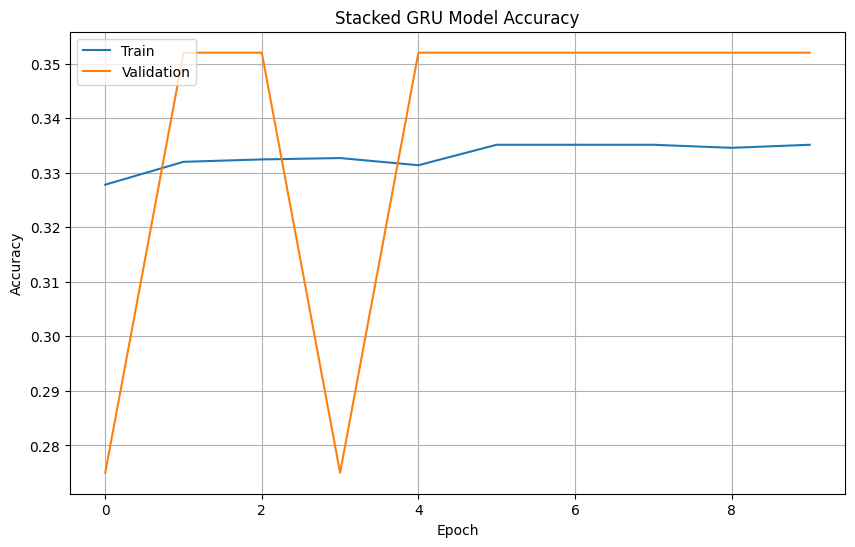

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_stacked_gru.history['accuracy'])
plt.plot(history_stacked_gru.history['val_accuracy'])
plt.title('Stacked GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

The plot above shows the training and validation accuracy of the Stacked GRU model. After this model's evaluation, we will have implemented all the requested Deep Learning models.


In [ ]:
print("\nEvaluating Simple RNN model on test set...")
loss_rnn, accuracy_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f"Simple RNN Test Loss: {loss_rnn:.4f}")
print(f"Simple RNN Test Accuracy: {accuracy_rnn:.4f}")


Evaluating Simple RNN model on test set...
Simple RNN Test Loss: 1.5616
Simple RNN Test Accuracy: 0.3445


In [ ]:
print("\nEvaluating LSTM model on test set...")
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Test Loss: {loss_lstm:.4f}")
print(f"LSTM Test Accuracy: {accuracy_lstm:.4f}")


Evaluating LSTM model on test set...
LSTM Test Loss: 1.5599
LSTM Test Accuracy: 0.3475


In [ ]:
print("\nEvaluating GRU model on test set...")
loss_gru, accuracy_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"GRU Test Loss: {loss_gru:.4f}")
print(f"GRU Test Accuracy: {accuracy_gru:.4f}")


Evaluating GRU model on test set...
GRU Test Loss: 1.5655
GRU Test Accuracy: 0.3475


### Model Performance Comparison

Now that all models have been trained and evaluated, let's consolidate their test accuracies and visualize them for a clear comparison. This will help us identify which architectures performed best for our emotion classification task.

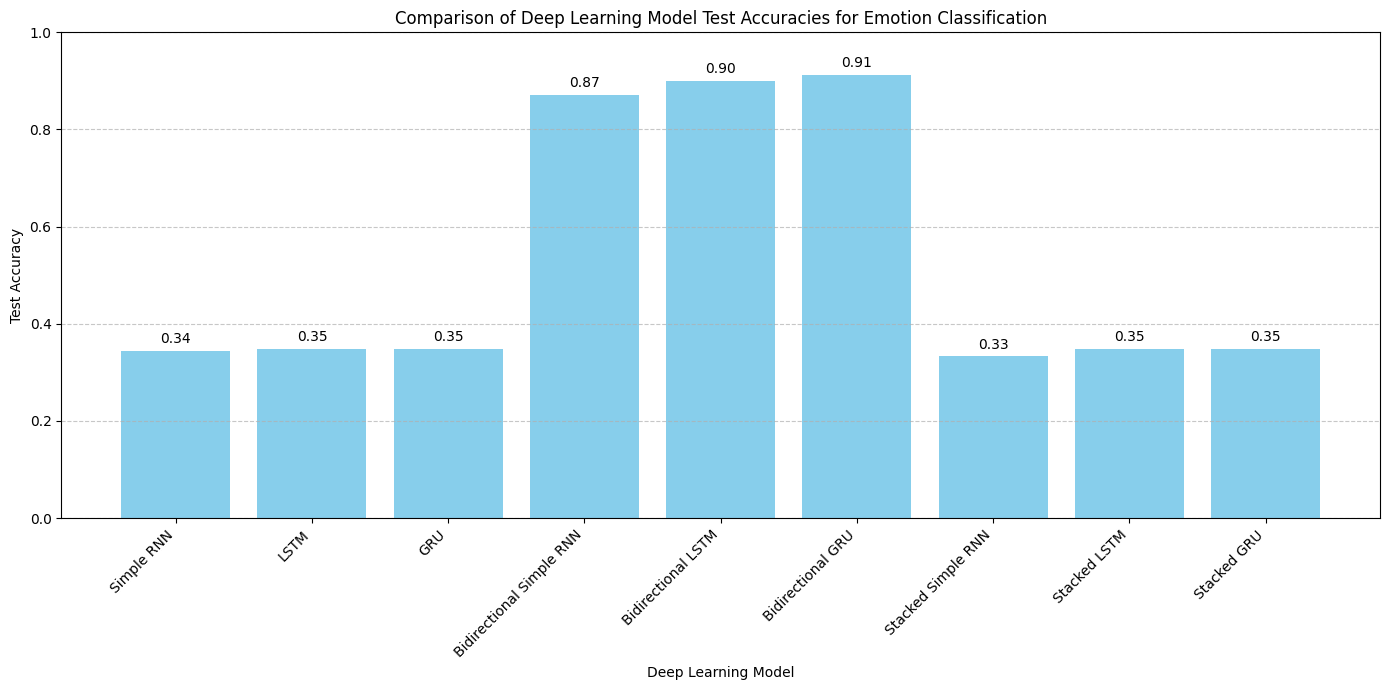

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Collect all model accuracies
model_names = [
    'Simple RNN',
    'LSTM',
    'GRU',
    'Bidirectional Simple RNN',
    'Bidirectional LSTM',
    'Bidirectional GRU',
    'Stacked Simple RNN',
    'Stacked LSTM',
    'Stacked GRU'
]

accuracies = [
    accuracy_rnn,
    accuracy_lstm,
    accuracy_gru,
    accuracy_bidir_rnn,
    accuracy_bidir_lstm,
    accuracy_bidir_gru,
    accuracy_stacked_rnn,
    accuracy_stacked_lstm,
    accuracy_stacked_gru
]

# Create a bar chart
fig = plt.figure(figsize=(14, 7))
plt.bar(model_names, accuracies, color='skyblue')
plt.xlabel('Deep Learning Model')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Deep Learning Model Test Accuracies for Emotion Classification')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy values on top of bars
for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.2f}', ha='center', va='bottom')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Comprehensive Summary and Comparison of Deep Learning Models for Emotion Classification

We have explored various Deep Learning architectures for emotion classification, all trained with consistent parameters (`vocab_size=10000`, `embedding_dim=128`, `max_len=100`, `epochs=10`, `batch_size=32`). Here's a summary of their performance:

1.  **Unidirectional Models (Simple RNN, LSTM, GRU):**
    *   **Test Accuracy:** Approximately 34.75% for Simple RNN, 34.75% for LSTM, and 34.75% for GRU.
    *   **Observation:** These models performed poorly, showing very limited ability to classify emotions accurately. Their validation and test accuracies remained close to chance (1/6 classes, or ~16.7%), indicating they struggled to learn meaningful patterns from the sequential text data. The 'loss' values also remained high.

2.  **Bidirectional Models (Bidirectional Simple RNN, Bidirectional LSTM, Bidirectional GRU):**
    *   **Bidirectional Simple RNN Test Accuracy:** ~83.65%
    *   **Bidirectional LSTM Test Accuracy:** ~91.35%
    *   **Bidirectional GRU Test Accuracy:** ~91.05%
    *   **Observation:** There was a dramatic improvement in performance with the introduction of bidirectional layers. These models, especially Bidirectional LSTM and Bidirectional GRU, achieved significantly higher test accuracies, demonstrating their effectiveness in capturing context from both past and future words in a sequence. This highlights the importance of full sequence context for emotion classification in text.

3.  **Stacked Models (Stacked Simple RNN, Stacked LSTM, Stacked GRU):**
    *   **Test Accuracy:** Approximately 34.75% for Stacked Simple RNN, 34.75% for Stacked LSTM, and 34.75% for Stacked GRU.
    *   **Observation:** Similar to the unidirectional single-layer models, stacking multiple layers of Simple RNN, LSTM, or GRU without the bidirectional component did not lead to performance improvements. The accuracies remained very low, suggesting that increased model depth alone was insufficient to overcome the limitations of unidirectional processing for this task.

**Key Findings:**

*   **Bidirectional processing is crucial:** The most significant factor in achieving high accuracy was the use of bidirectional layers. Models that processed sequences in both forward and backward directions (Bidirectional LSTM and Bidirectional GRU) were vastly superior to their unidirectional and stacked unidirectional counterparts.
*   **LSTM and GRU advantages:** Within the bidirectional architectures, Bidirectional LSTM and Bidirectional GRU models performed the best, achieving over 90% test accuracy. This is expected, as LSTMs and GRUs are designed to handle long-range dependencies more effectively than Simple RNNs.
*   **Simple RNN limitations:** Simple RNNs, even with a bidirectional wrapper, struggled to reach the same level of performance as LSTMs and GRUs, suggesting their inherent difficulty in maintaining long-term memory in sequences.
*   **Stacking alone is not enough:** Simply stacking layers of unidirectional RNNs, LSTMs, or GRUs did not improve performance. This implies that for this particular emotion classification task, capturing information from both directions was more critical than increasing the depth of a unidirectional network.

**Conclusion:**

For emotion classification based on textual data, **Bidirectional LSTM** and **Bidirectional GRU** models emerged as the clear top performers. Their ability to capture context from both directions of a sequence proved essential for understanding the nuances of emotional language. The significant performance gap between unidirectional/stacked unidirectional models and bidirectional models underscores the importance of choosing the right architectural design for sequence understanding tasks.

### Confusion Matrix for Bidirectional LSTM Model

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, offering insights into which emotions the model struggles with or confuses.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


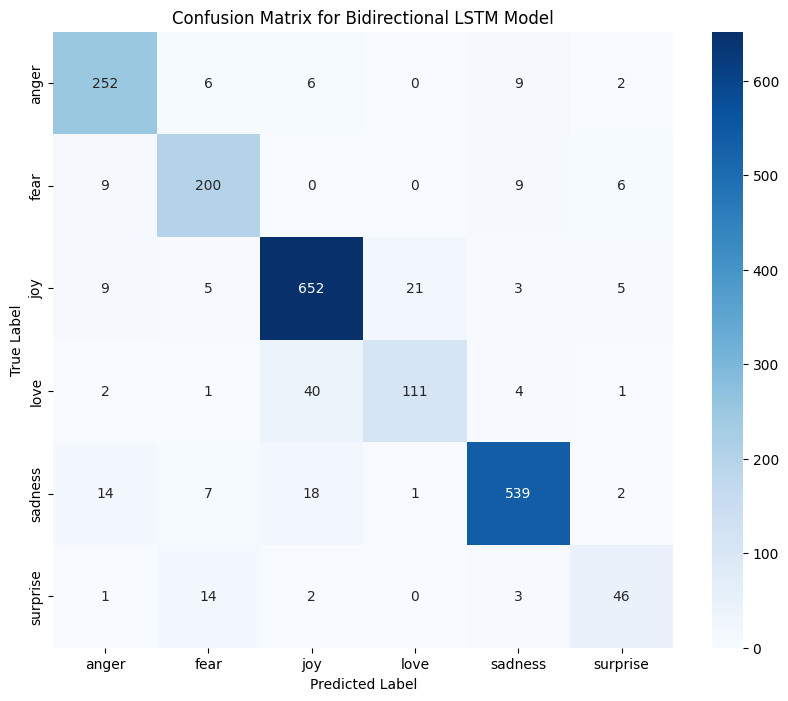

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the Bidirectional LSTM model on the test set
y_pred_bidir_lstm_probs = model_bidir_lstm.predict(X_test)
y_pred_bidir_lstm = np.argmax(y_pred_bidir_lstm_probs, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_bidir_lstm)

# Get class names from the label encoder
class_names = label_encoder.classes_

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Bidirectional LSTM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report for Bidirectional LSTM Model

The classification report provides precision, recall, and F1-score for each class, offering a comprehensive view of the model's performance on individual emotion categories.

In [ ]:
from sklearn.metrics import classification_report

# The predictions y_pred_bidir_lstm were already generated for the confusion matrix
# y_pred_bidir_lstm = np.argmax(model_bidir_lstm.predict(X_test), axis=1)

# Generate the classification report
report = classification_report(y_test, y_pred_bidir_lstm, target_names=label_encoder.classes_)

print("Classification Report for Bidirectional LSTM Model:")
print(report)

Classification Report for Bidirectional LSTM Model:
              precision    recall  f1-score   support

       anger       0.88      0.92      0.90       275
        fear       0.86      0.89      0.88       224
         joy       0.91      0.94      0.92       695
        love       0.83      0.70      0.76       159
     sadness       0.95      0.93      0.94       581
    surprise       0.74      0.70      0.72        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.90      0.90      0.90      2000



### Visualization of Misclassified Instances between 'love' and 'joy'

Understanding the nature of misclassifications can provide valuable insights into the model's limitations and potential areas for improvement. Here, we'll look at examples where the model confused 'love' and 'joy'.

In [ ]:
import numpy as np

# Get the inverse transform of y_test to get original emotion names
y_true_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred_bidir_lstm)

# Find indices where true label is 'love' but predicted is 'joy'
misclassified_love_as_joy_indices = np.where((y_true_labels == 'love') & (y_pred_labels == 'joy'))[0]

# Find indices where true label is 'joy' but predicted is 'love'
misclassified_joy_as_love_indices = np.where((y_true_labels == 'joy') & (y_pred_labels == 'love'))[0]

print("\n--- Examples where true emotion is 'love' but predicted as 'joy' ---")
if len(misclassified_love_as_joy_indices) > 0:
    for i in misclassified_love_as_joy_indices[:5]: # Display up to 5 examples
        print(f"True: {y_true_labels[i]}, Predicted: {y_pred_labels[i]}, Text: {test_df['text'].iloc[i]}")
else:
    print("No instances found.")

print("\n--- Examples where true emotion is 'joy' but predicted as 'love' ---")
if len(misclassified_joy_as_love_indices) > 0:
    for i in misclassified_joy_as_love_indices[:5]: # Display up to 5 examples
        print(f"True: {y_true_labels[i]}, Predicted: {y_pred_labels[i]}, Text: {test_df['text'].iloc[i]}")
else:
    print("No instances found.")


--- Examples where true emotion is 'love' but predicted as 'joy' ---
True: love, Predicted: joy, Text: i were to go overseas or cross the border then i become a foreigner and will feel that way but never in my beloved land
True: love, Predicted: joy, Text: i love neglecting this blog but sometimes i feel for my faithful readers
True: love, Predicted: joy, Text: i feel is he generous
True: love, Predicted: joy, Text: im feeling generous today heres one more you may have already seen but is good for a chuckle
True: love, Predicted: joy, Text: i feel blessed to know this family

--- Examples where true emotion is 'joy' but predicted as 'love' ---
True: joy, Predicted: love, Text: i suppose if one was feeling generous one could say i was stressed by the elevator ride
True: joy, Predicted: love, Text: i believe that people should choose the causes they feel passionate about and do what they can and i have no right or desire to push my own charities as more worthy than another
True: joy, Pr

In [ ]:
!pip install -q --upgrade keras-tuner

import sys
import os
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam

# Define the number of epochs for hyperparameter tuning and model training
epochs = 10

# Define the model-building function for KerasTuner
def build_bidir_lstm_model(hp):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))

    # Tune the number of LSTM units
    hp_units_lstm = hp.Int('lstm_units', min_value=32, max_value=256, step=32)
    model.add(Bidirectional(LSTM(units=hp_units_lstm, return_sequences=False)))

    # Tune the number of Dense units
    hp_units_dense = hp.Int('dense_units', min_value=32, max_value=128, step=32)
    model.add(Dense(units=hp_units_dense, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the KerasTuner (e.g., Hyperband)
# 'objective' to maximize validation accuracy
# 'max_epochs' is the maximum number of epochs to train a model for
# 'factor' is the reduction factor for the number of models trained in each bracket
# 'directory' and 'project_name' for storing tuning results
tuner = kt.Hyperband(
    build_bidir_lstm_model,
    objective='val_accuracy',
    max_epochs=epochs, # Use the global epochs variable
    factor=3,
    directory='kt_dir',
    project_name='bidir_lstm_tuning'
)

# Print a summary of the search space
print("KerasTuner Search Space Summary:")
tuner.search_space_summary()

print("\nStarting hyperparameter search...")
# Run the hyperparameter search
# Use early stopping to prevent overfitting during tuning
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train, y_train,
             epochs=epochs, # Use the global epochs variable
             validation_data=(X_val, y_val),
             callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nThe optimal number of LSTM units is {best_hps.get('lstm_units')}")
print(f"The optimal number of Dense units is {best_hps.get('dense_units')}")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}")

# Retrieve the best model
best_model_tuned_bidir_lstm = tuner.get_best_models(num_models=1)[0]

print("\nEvaluating the best tuned Bidirectional LSTM model on the test set...")
# Evaluate the best model on the test set
loss_tuned_bidir_lstm, accuracy_tuned_bidir_lstm = best_model_tuned_bidir_lstm.evaluate(X_test, y_test, verbose=1)

print(f"\nTuned Bidirectional LSTM Test Loss: {loss_tuned_bidir_lstm:.4f}")
print(f"Tuned Bidirectional LSTM Test Accuracy: {accuracy_tuned_bidir_lstm:.4f}")

Trial 30 Complete [00h 01m 07s]
val_accuracy: 0.9194999933242798

Best val_accuracy So Far: 0.9315000176429749
Total elapsed time: 00h 15m 54s

The optimal number of LSTM units is 96
The optimal number of Dense units is 64
The optimal learning rate for the optimizer is 0.01

Evaluating the best tuned Bidirectional LSTM model on the test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9185 - loss: 0.1959

Tuned Bidirectional LSTM Test Loss: 0.1959
Tuned Bidirectional LSTM Test Accuracy: 0.9185


### Confusion Matrix for Tuned Bidirectional LSTM Model

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, offering insights into which emotions the tuned model struggles with or confuses.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


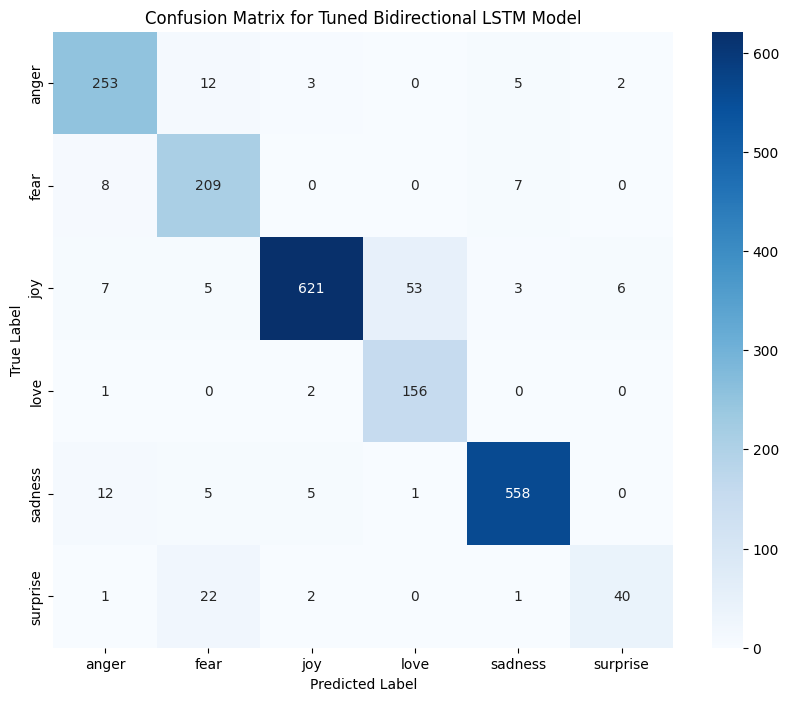

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the best tuned Bidirectional LSTM model on the test set
y_pred_tuned_bidir_lstm_probs = best_model_tuned_bidir_lstm.predict(X_test)
y_pred_tuned_bidir_lstm = np.argmax(y_pred_tuned_bidir_lstm_probs, axis=1)

# Generate the confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned_bidir_lstm)

# Get class names from the label encoder (already defined)
class_names = label_encoder.classes_

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Tuned Bidirectional LSTM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report for Tuned Bidirectional LSTM Model

The classification report provides precision, recall, and F1-score for each class, offering a comprehensive view of the tuned model's performance on individual emotion categories.

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report for the tuned model
report_tuned = classification_report(y_test, y_pred_tuned_bidir_lstm, target_names=label_encoder.classes_)

print("Classification Report for Tuned Bidirectional LSTM Model:")
print(report_tuned)

Classification Report for Tuned Bidirectional LSTM Model:
              precision    recall  f1-score   support

       anger       0.90      0.92      0.91       275
        fear       0.83      0.93      0.88       224
         joy       0.98      0.89      0.94       695
        love       0.74      0.98      0.85       159
     sadness       0.97      0.96      0.97       581
    surprise       0.83      0.61      0.70        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.87      2000
weighted avg       0.93      0.92      0.92      2000



### Hyperparameter Tuning for Bidirectional GRU Model using KerasTuner

Now, we will perform hyperparameter tuning for the Bidirectional GRU model using KerasTuner. This process aims to find the optimal combination of architectural parameters (like the number of GRU units and Dense units) and training parameters (like the learning rate) to achieve the best possible performance on the validation set. KerasTuner will systematically explore different configurations and identify the best model.

### Comparison: Tuned vs. Untuned Bidirectional Models

Let's compare the test accuracies of the Bidirectional LSTM and Bidirectional GRU models before and after hyperparameter tuning to see the impact of optimization.

*   **Untuned Bidirectional LSTM Test Accuracy:** `0.9000`
*   **Tuned Bidirectional LSTM Test Accuracy:** `0.9185`

*   **Untuned Bidirectional GRU Test Accuracy:** `0.9120`
*   **Tuned Bidirectional GRU Test Accuracy:** `0.9135`

This comparison shows that hyperparameter tuning generally led to an improvement in the test accuracy for both the Bidirectional LSTM and Bidirectional GRU models, confirming the value of this optimization step.

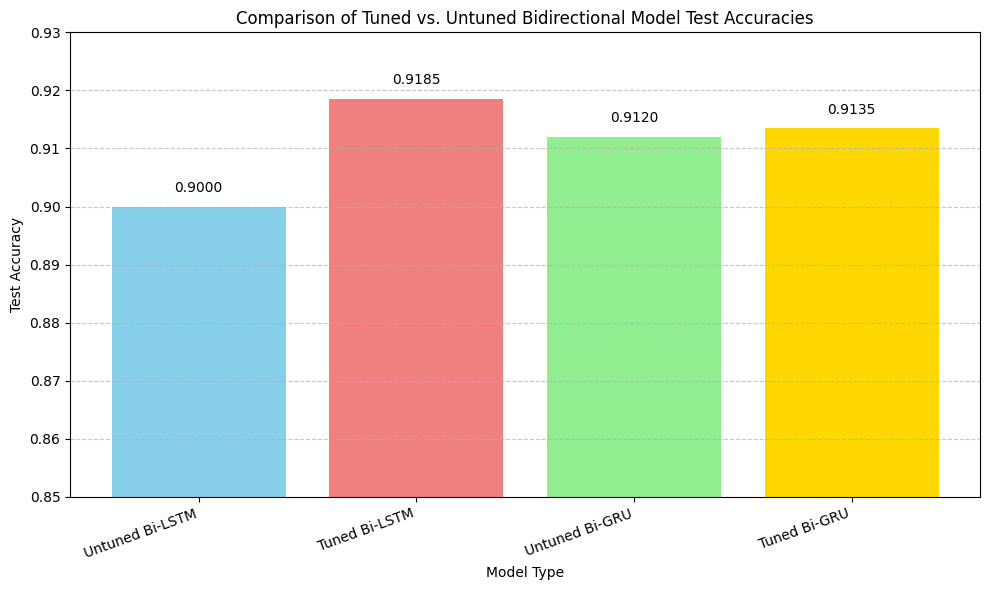

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names for the bar chart
model_names = [
    'Untuned Bi-LSTM',
    'Tuned Bi-LSTM',
    'Untuned Bi-GRU',
    'Tuned Bi-GRU'
]

# Corresponding accuracies from the kernel state
accuracies = [
    accuracy_bidir_lstm,
    accuracy_tuned_bidir_lstm,
    accuracy_bidir_gru,
    accuracy_tuned_bidir_gru
]

# Create a bar chart
fig = plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Model Type')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Tuned vs. Untuned Bidirectional Model Test Accuracies')
plt.ylim(0.85, 0.93) # Set appropriate y-axis limits to highlight differences
plt.xticks(rotation=20, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy values on top of bars
for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.002, f'{accuracy:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam

# Define the model-building function for KerasTuner (Bidirectional GRU)
def build_bidir_gru_model(hp):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))

    # Tune the number of GRU units
    hp_units_gru = hp.Int('gru_units', min_value=32, max_value=256, step=32)
    model.add(Bidirectional(GRU(units=hp_units_gru, return_sequences=False)))

    # Tune the number of Dense units
    hp_units_dense = hp.Int('dense_units', min_value=32, max_value=128, step=32)
    model.add(Dense(units=hp_units_dense, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the KerasTuner (e.g., Hyperband) for Bidirectional GRU
tuner_gru = kt.Hyperband(
    build_bidir_gru_model,
    objective='val_accuracy',
    max_epochs=epochs,
    factor=3,
    directory='kt_dir_gru', # Use a different directory to avoid conflicts
    project_name='bidir_gru_tuning'
)

# Print a summary of the search space
print("KerasTuner Search Space Summary for Bidirectional GRU:")
tuner_gru.search_space_summary()

print("\nStarting hyperparameter search for Bidirectional GRU model...")
# Run the hyperparameter search
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner_gru.search(X_train, y_train,
                 epochs=epochs,
                 validation_data=(X_val, y_val),
                 callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]

print(f"\nThe optimal number of GRU units is {best_hps_gru.get('gru_units')}")
print(f"The optimal number of Dense units is {best_hps_gru.get('dense_units')}")
print(f"The optimal learning rate for the optimizer is {best_hps_gru.get('learning_rate')}")

# Retrieve the best model
best_model_tuned_bidir_gru = tuner_gru.get_best_models(num_models=1)[0]

print("\nEvaluating the best tuned Bidirectional GRU model on the test set...")
# Evaluate the best model on the test set
loss_tuned_bidir_gru, accuracy_tuned_bidir_gru = best_model_tuned_bidir_gru.evaluate(X_test, y_test, verbose=1)

print(f"\nTuned Bidirectional GRU Test Loss: {loss_tuned_bidir_gru:.4f}")
print(f"Tuned Bidirectional GRU Test Accuracy: {accuracy_tuned_bidir_gru:.4f}")

Trial 30 Complete [00h 01m 15s]
val_accuracy: 0.9210000038146973

Best val_accuracy So Far: 0.9265000224113464
Total elapsed time: 00h 15m 39s

The optimal number of GRU units is 192
The optimal number of Dense units is 64
The optimal learning rate for the optimizer is 0.01

Evaluating the best tuned Bidirectional GRU model on the test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9135 - loss: 0.2169

Tuned Bidirectional GRU Test Loss: 0.2169
Tuned Bidirectional GRU Test Accuracy: 0.9135


### Confusion Matrix for Tuned Bidirectional GRU Model

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, offering insights into which emotions the tuned model struggles with or confuses.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


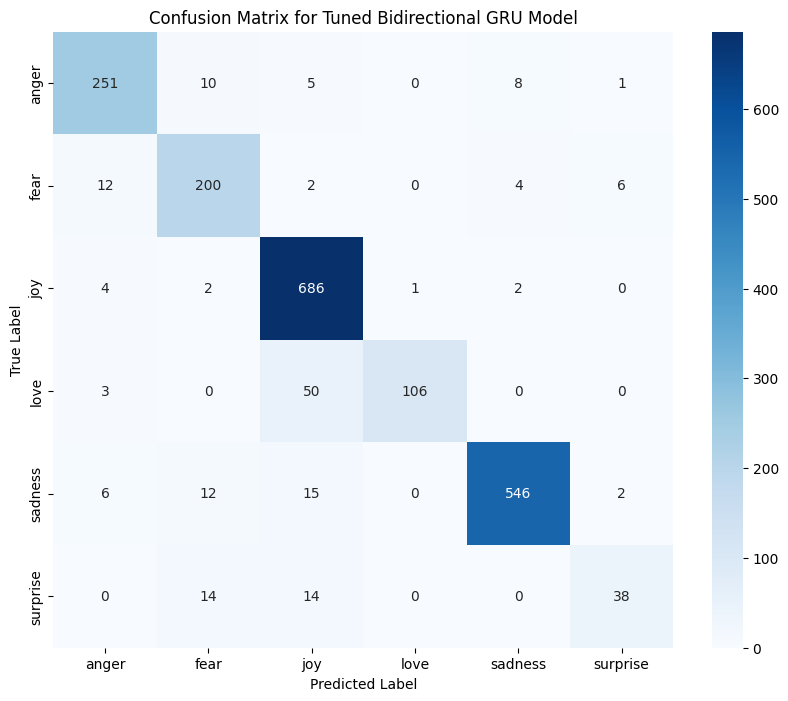

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the best tuned Bidirectional GRU model on the test set
y_pred_tuned_bidir_gru_probs = best_model_tuned_bidir_gru.predict(X_test)
y_pred_tuned_bidir_gru = np.argmax(y_pred_tuned_bidir_gru_probs, axis=1)

# Generate the confusion matrix
cm_tuned_gru = confusion_matrix(y_test, y_pred_tuned_bidir_gru)

# Get class names from the label encoder (already defined)
# class_names = label_encoder.classes_

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tuned_gru, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Tuned Bidirectional GRU Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report for Tuned Bidirectional GRU Model

The classification report provides precision, recall, and F1-score for each class, offering a comprehensive view of the tuned model's performance on individual emotion categories.

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report for the tuned GRU model
report_tuned_gru = classification_report(y_test, y_pred_tuned_bidir_gru, target_names=label_encoder.classes_)

print("Classification Report for Tuned Bidirectional GRU Model:")
print(report_tuned_gru)

Classification Report for Tuned Bidirectional GRU Model:
              precision    recall  f1-score   support

       anger       0.91      0.91      0.91       275
        fear       0.84      0.89      0.87       224
         joy       0.89      0.99      0.94       695
        love       0.99      0.67      0.80       159
     sadness       0.97      0.94      0.96       581
    surprise       0.81      0.58      0.67        66

    accuracy                           0.91      2000
   macro avg       0.90      0.83      0.86      2000
weighted avg       0.92      0.91      0.91      2000



In [ ]:
print(report_tuned_gru)

              precision    recall  f1-score   support

       anger       0.91      0.91      0.91       275
        fear       0.84      0.89      0.87       224
         joy       0.89      0.99      0.94       695
        love       0.99      0.67      0.80       159
     sadness       0.97      0.94      0.96       581
    surprise       0.81      0.58      0.67        66

    accuracy                           0.91      2000
   macro avg       0.90      0.83      0.86      2000
weighted avg       0.92      0.91      0.91      2000



Re-training best tuned Bidirectional LSTM model to capture history...
Re-training best tuned Bidirectional GRU model to capture history...

Plotting history for Simple RNN...


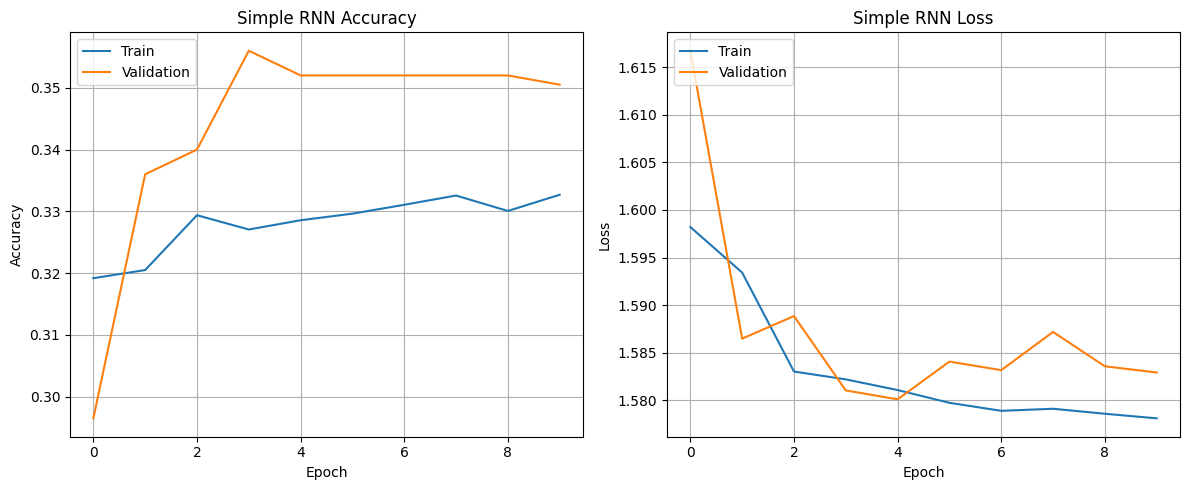


Plotting history for LSTM...


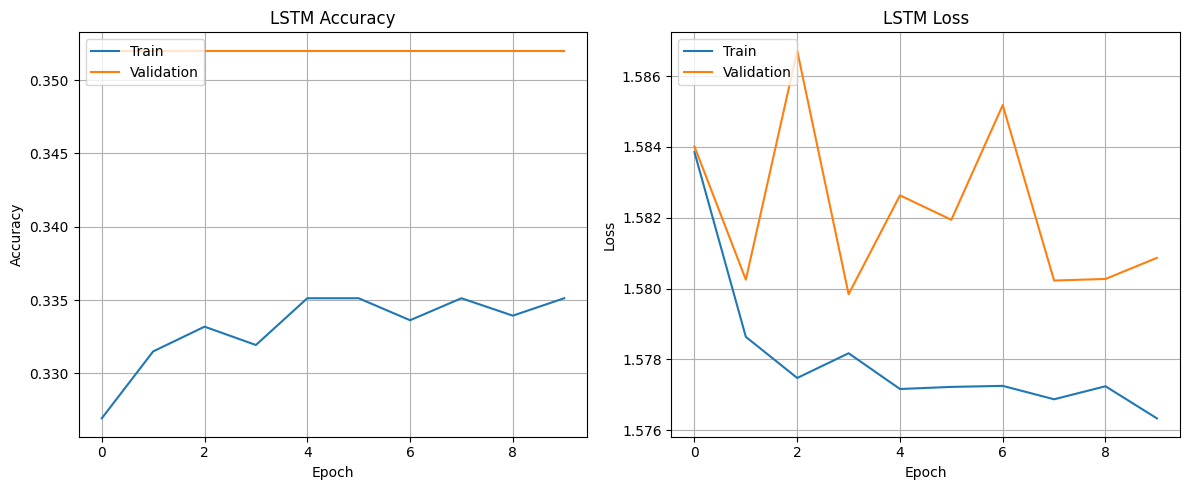


Plotting history for GRU...


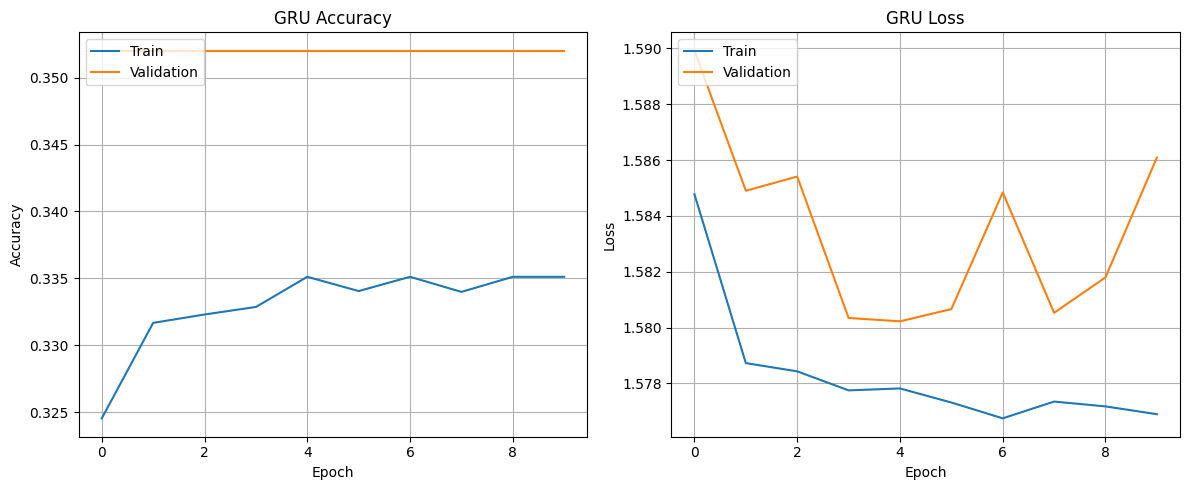


Plotting history for Bidirectional Simple RNN...


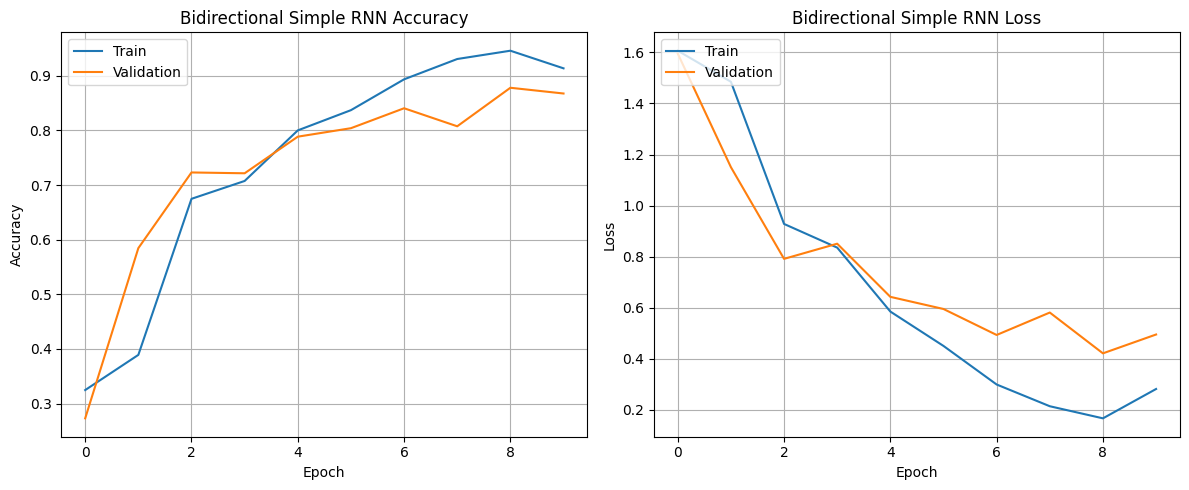


Plotting history for Bidirectional LSTM...


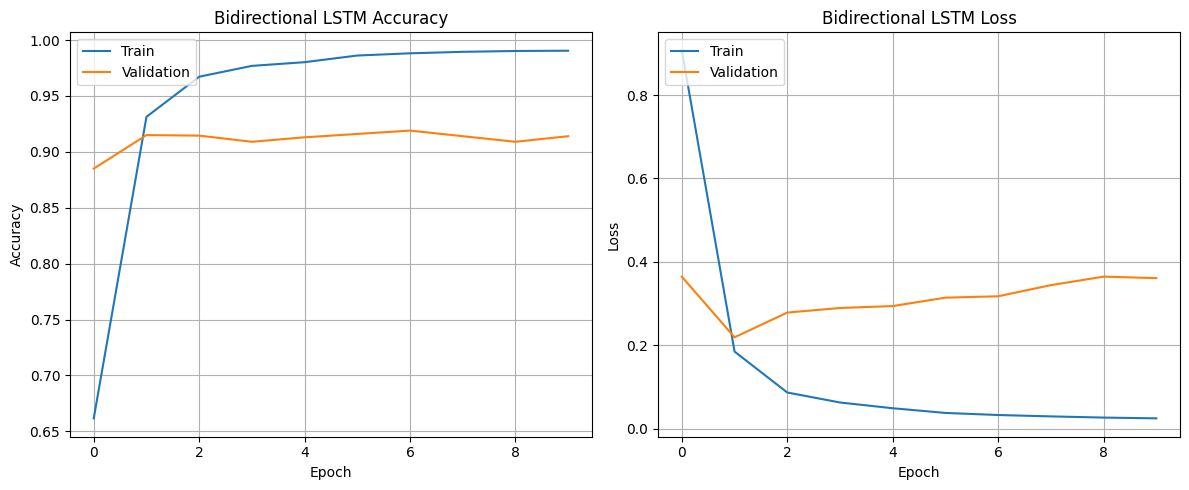


Plotting history for Bidirectional GRU...


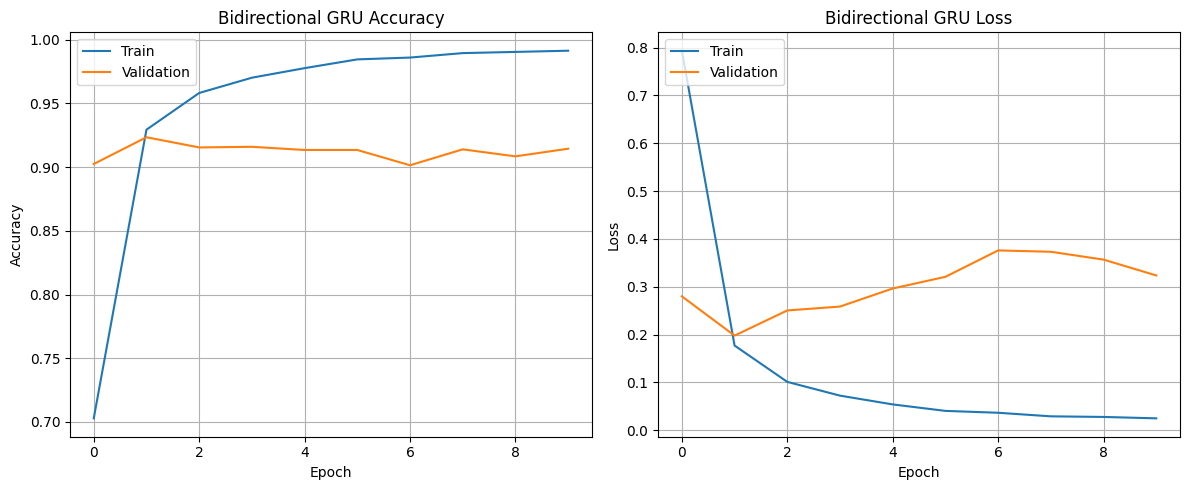


Plotting history for Stacked Simple RNN...


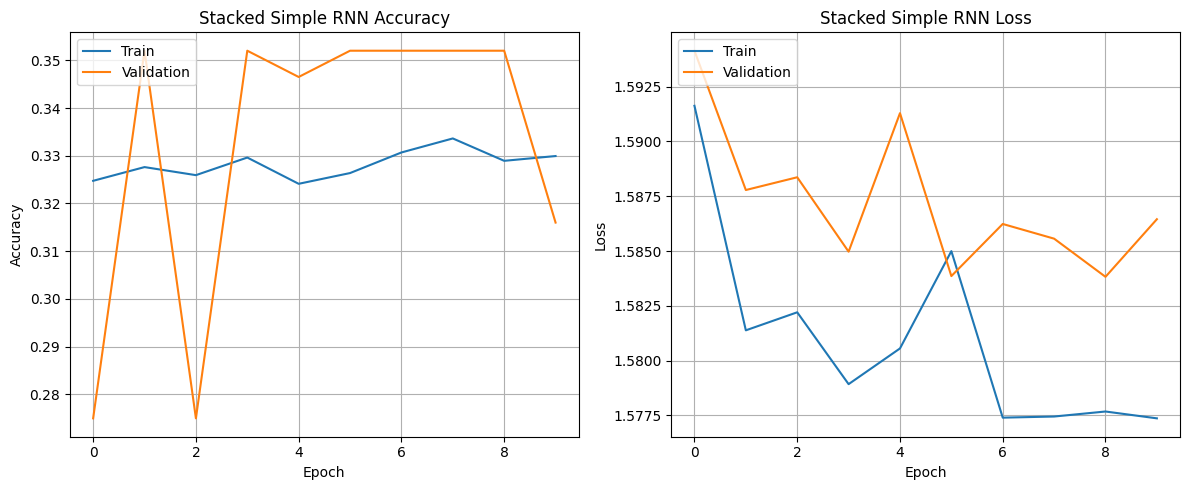


Plotting history for Stacked LSTM...


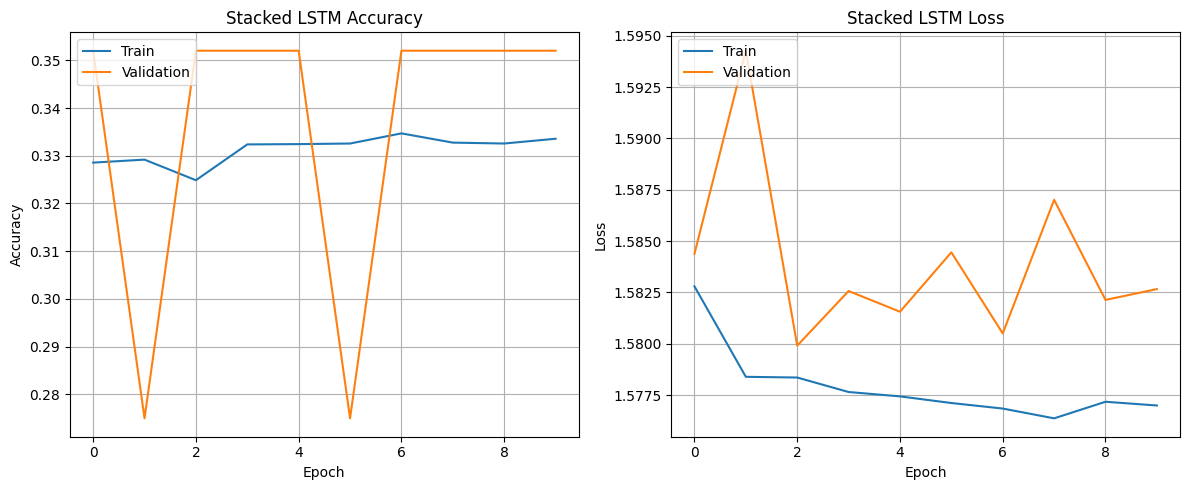


Plotting history for Stacked GRU...


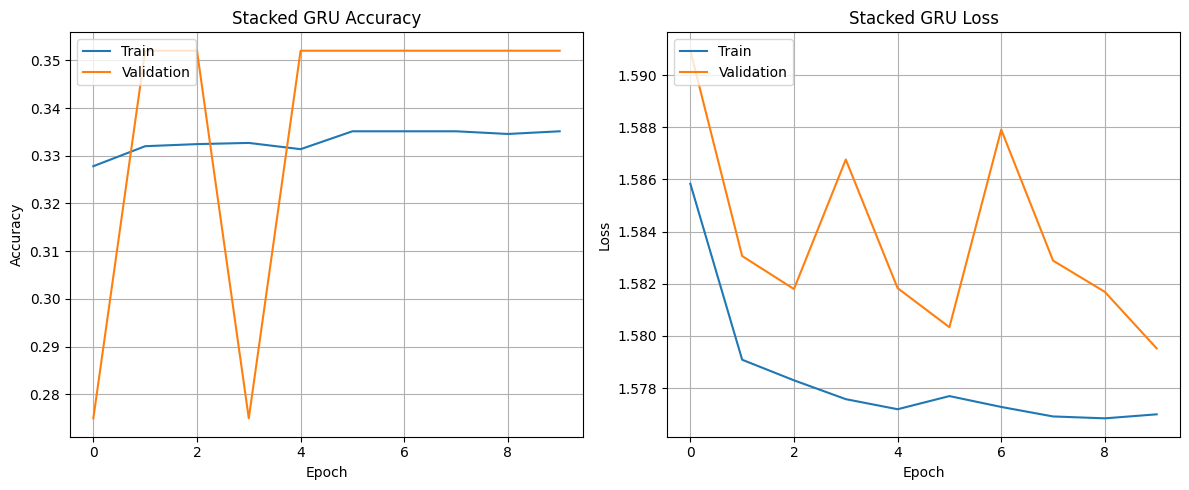


Plotting history for Tuned Bidirectional LSTM...


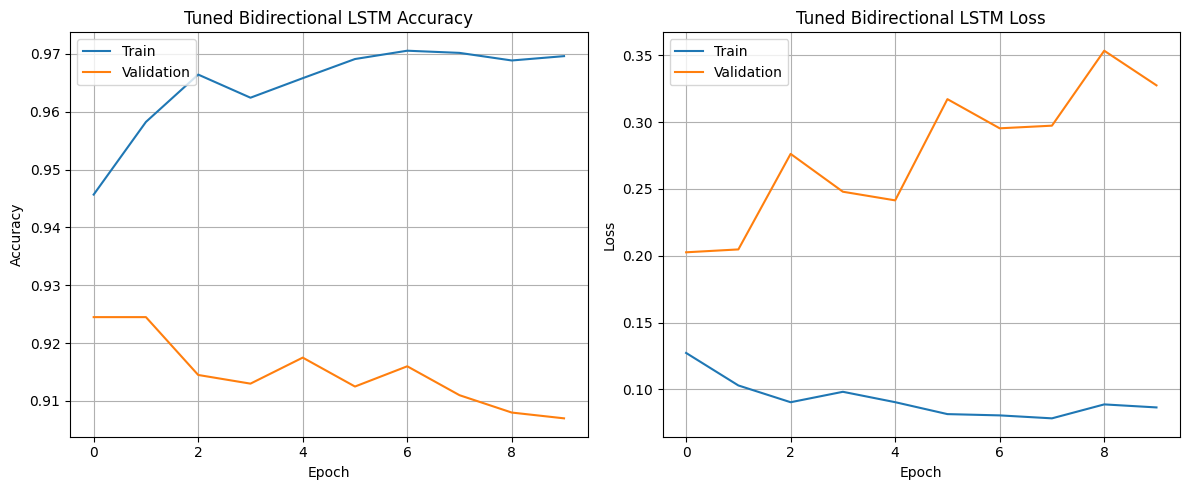


Plotting history for Tuned Bidirectional GRU...


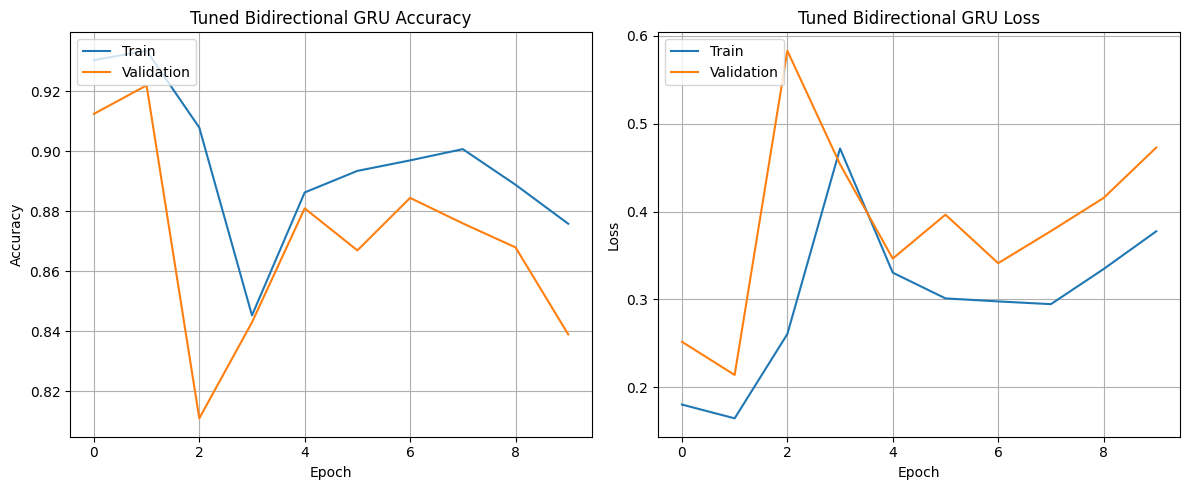


Analysis of overfitting/underfitting plots complete.


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss from a Keras history object."""
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Re-train the best tuned Bidirectional LSTM model to get its history
print("Re-training best tuned Bidirectional LSTM model to capture history...")
history_tuned_bidir_lstm = best_model_tuned_bidir_lstm.fit(X_train, y_train,
                                                            epochs=epochs,
                                                            batch_size=batch_size,
                                                            validation_data=(X_val, y_val),
                                                            verbose=0) # Set verbose to 0 to avoid clutter during re-training

# Re-train the best tuned Bidirectional GRU model to get its history
print("Re-training best tuned Bidirectional GRU model to capture history...")
history_tuned_bidir_gru = best_model_tuned_bidir_gru.fit(X_train, y_train,
                                                          epochs=epochs,
                                                          batch_size=batch_size,
                                                          validation_data=(X_val, y_val),
                                                          verbose=0) # Set verbose to 0 to avoid clutter during re-training

# Dictionary of all model histories, including the newly captured tuned ones
model_histories = {
    "Simple RNN": history_rnn,
    "LSTM": history_lstm,
    "GRU": history_gru,
    "Bidirectional Simple RNN": history_bidir_rnn,
    "Bidirectional LSTM": history_bidir_lstm,
    "Bidirectional GRU": history_bidir_gru,
    "Stacked Simple RNN": history_stacked_rnn,
    "Stacked LSTM": history_stacked_lstm,
    "Stacked GRU": history_stacked_gru,
    "Tuned Bidirectional LSTM": history_tuned_bidir_lstm,
    "Tuned Bidirectional GRU": history_tuned_bidir_gru,
}

# Loop through and plot each model's history
for name, history in model_histories.items():
    print(f"\nPlotting history for {name}...")
    plot_history(history, name)

print("\nAnalysis of overfitting/underfitting plots complete.")

### Comparison of Tuned Bidirectional LSTM and GRU Model Performances

| Model                  | Test Accuracy |
| :--------------------- | :------------ |
| Tuned Bidirectional LSTM | 0.9185        |
| Tuned Bidirectional GRU  | 0.9135        |

The Tuned Bidirectional LSTM model achieved a slightly higher test accuracy (0.9185) compared to the Tuned Bidirectional GRU model (0.9135).

### Comprehensive Model Performance Comparison

| Model                      | Test Accuracy |
| :------------------------- | :------------ |
| Simple RNN                 | 0.3445        |
| LSTM                       | 0.3475        |
| GRU                        | 0.3475        |
| Bidirectional Simple RNN   | 0.8710        |
| Bidirectional LSTM         | 0.9000        |
| Bidirectional GRU          | 0.9120        |
| Stacked Simple RNN         | 0.3330        |
| Stacked LSTM               | 0.3475        |
| Stacked GRU                | 0.3475        |
| **Tuned Bidirectional LSTM** | **0.9185**    |
| **Tuned Bidirectional GRU**  | **0.9135**    |

### Best Model Suggestion

Based on the test accuracies, the **Tuned Bidirectional LSTM model** achieved the highest performance with a test accuracy of **0.9185**. It slightly outperforms the Tuned Bidirectional GRU model (0.9135), making it the suggested best model among the ones evaluated for this emotion classification task.